# 第八階段:用接球員的運動修正傳球路徑

**最終目標**:做一個「傳球空間分析」工具,給教練或球探使用。

**本階段只做一件事**:嘗試修正第六階段 passing lane 的已知侷限 —— 它把路徑終點設成「接球員**當下**位置」,對深傳失真。我們改用接球員自己的運動外推「預測落點」當路徑終點,然後**用資料檢驗這個修正到底有沒有效**。

**先講結論(本階段的收穫)**:這個修正**沒有**解決痛點 —— 對示範的深傳 play,改用預測落點後路徑反而更擠。真正的根因是 passing lane 只看平面距離、不看球的高度與弧線,所以**換路徑終點修不了它**。這一階段的價值不是「修好了」,而是**用資料證明了這條路行不通,並定位出真正的根因**。

---

### 重要:先講清楚資料能做什麼、不能做什麼

原本最理想的修法是「用球實際飛到的落點」當路徑終點。但**這份資料做不到**:

- 整場 92 個傳球 play,只有 **3 個**有 `pass_arrived`(球抵達)、**1 個**有 `pass_outcome_caught`(接到)。
- tracking 幾乎在傳球瞬間就截斷,**沒有球飛行的完整軌跡**,也沒有落點座標欄位。

所以我們不硬湊一個資料撐不起來的方法。改用**資料裡真實存在**的東西:接球員傳球瞬間的**速度 `s`** 與**方向 `dir`**,用等速外推預測他的落點。這是一個誠實、可驗證的近似。

### 為什麼這個近似可信?(已驗證)

以 `playId=137` 的 Amari Cooper 為例:傳球瞬間在 (98.8, 9.6)、速度 8.1 碼/秒、方向 242°。外推 0.5 秒得 (95.2, 7.7),而他片段最後一個 frame 的真實位置是 (95.1, 7.8) —— 幾乎完全吻合。短時間的等速外推對這種跑動是合理的。

## 步驟 0:載入工具與設定路徑

- **輸入**:無
- **輸出**:工具與路徑
- **目的**:準備工具,跟前幾階段一樣。

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["PingFang TC", "Heiti TC", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

sys.path.append(str(Path.cwd().parent))
from config import DATA_DIR, SAMPLE_GAME_ID

SAMPLE_PLAY_ID = 137
print("gameId:", SAMPLE_GAME_ID, "/ playId:", SAMPLE_PLAY_ID)

gameId: 2021090900 / playId: 137


## 步驟 1:重建傳球瞬間的場上狀態(含速度與方向)

- **輸入**:`tracking`、`plays`、`players`、`pff`
- **輸出**:`frame`(傳球瞬間每位球員,含 `s`、`dir`、角色)
- **目的**:這一階段比第六階段多需要兩個欄位:`s`(速度,碼/秒)、`dir`(移動方向,度)。它們是外推預測落點的原料。

> `dir` 是 NFL tracking 的移動方向:0° = 朝 y 軸正向、90° = 朝 x 軸正向(順時針)。

In [2]:
plays = pd.read_csv(DATA_DIR / "plays.csv")
players = pd.read_csv(DATA_DIR / "players.csv")
pff = pd.read_csv(DATA_DIR / "pffScoutingData.csv")
tracking = pd.read_csv(DATA_DIR / "tracking" / f"tracking_{SAMPLE_GAME_ID}.csv")

this_play = plays[(plays["gameId"] == SAMPLE_GAME_ID) & (plays["playId"] == SAMPLE_PLAY_ID)]
play_track = tracking[
    (tracking["gameId"] == SAMPLE_GAME_ID) & (tracking["playId"] == SAMPLE_PLAY_ID)
].copy()
pass_frame = play_track.loc[play_track["event"] == "pass_forward", "frameId"].iloc[0]

roles = pff[
    (pff["gameId"] == SAMPLE_GAME_ID) & (pff["playId"] == SAMPLE_PLAY_ID)
][["nflId", "pff_role"]]
frame = (
    play_track[(play_track["frameId"] == pass_frame) & play_track["nflId"].notna()]
    .merge(players[["nflId", "displayName"]], on="nflId", how="left")
    .merge(roles, on="nflId", how="left")
)

qb_row = frame[frame["pff_role"] == "Pass"].iloc[0]
qb_xy = (qb_row["x"], qb_row["y"])
receivers = frame[frame["pff_role"] == "Pass Route"].copy()
defenders = frame[frame["pff_role"] == "Coverage"].copy()
print("QB:", qb_row["displayName"], "/ 接球員", len(receivers), "位 / 防守員", len(defenders), "位")
print(receivers[["displayName", "x", "y", "s", "dir"]].to_string(index=False))

QB: Dak Prescott / 接球員 5 位 / 防守員 6 位
    displayName      x     y    s    dir
   Amari Cooper  98.79  9.57 8.09 241.78
Ezekiel Elliott  98.77 44.72 7.17 274.88
   Blake Jarwin 104.85 44.62 5.65 349.99
 Dalton Schultz 103.89 34.39 0.60  36.66
    CeeDee Lamb 103.66  6.06 1.10 236.46


## 步驟 2:把速度 + 方向換成預測落點

- **輸入**:接球員的 `x`、`y`、`s`、`dir`、假設的球飛行時間 `T`
- **輸出**:預測落點 `(pred_x, pred_y)`
- **目的**:等速外推。把方向 `dir` 拆成 x / y 兩個分量,乘上飛行時間,加到當下位置。

**公式**(dir 的 0°=+y、90°=+x):
- `vx = s · sin(dir)`、`vy = s · cos(dir)`
- `pred_x = x + vx · T`、`pred_y = y + vy · T`

> `T` 用一個合理的估計值。深傳球在空中約 1 秒上下,這裡取 `T = 0.8` 秒當預設,後面會說明它的影響。

In [3]:
BALL_FLIGHT_T = 0.8  # 假設的球飛行時間(秒)

def predict_landing(x, y, s, direction, T=BALL_FLIGHT_T):
    rad = np.radians(direction)
    vx = s * np.sin(rad)   # dir: 90°=+x
    vy = s * np.cos(rad)   # dir: 0°=+y
    return x + vx * T, y + vy * T


# 驗證:Cooper 外推 0.5 秒應接近他片段最後位置 (95.1, 7.8)
c = receivers[receivers["displayName"] == "Amari Cooper"].iloc[0]
chk = predict_landing(c["x"], c["y"], c["s"], c["dir"], T=0.5)
print(f"Cooper 外推 0.5s: ({chk[0]:.1f}, {chk[1]:.1f}) — 真實最後位置約 (95.1, 7.8),吻合")

# 算每位接球員的預測落點
receivers = receivers.copy()
pred = receivers.apply(lambda r: predict_landing(r["x"], r["y"], r["s"], r["dir"]), axis=1)
receivers["pred_x"] = [p[0] for p in pred]
receivers["pred_y"] = [p[1] for p in pred]
print()
print(receivers[["displayName", "x", "y", "pred_x", "pred_y"]].round(1).to_string(index=False))

Cooper 外推 0.5s: (95.2, 7.7) — 真實最後位置約 (95.1, 7.8),吻合

    displayName     x    y  pred_x  pred_y
   Amari Cooper  98.8  9.6    93.1     6.5
Ezekiel Elliott  98.8 44.7    93.1    45.2
   Blake Jarwin 104.8 44.6   104.1    49.1
 Dalton Schultz 103.9 34.4   104.2    34.8
    CeeDee Lamb 103.7  6.1   102.9     5.6


## 步驟 3:比較「當下位置」vs「預測落點」兩種路徑的風險

- **輸入**:QB、接球員當下位置、接球員預測落點、防守員
- **輸出**:DataFrame `compare`(每位接球員兩種路徑的最近擋路者距離)
- **目的**:這是本階段的重點 —— 直接比較修正前(第六階段:QB→當下位置)與修正後(QB→預測落點)。

> 用的還是第六階段的「點到線段距離 + 投影參數」幾何,只是把線段終點換成預測落點。

In [4]:
def _point_to_segment(px, py, ax0, ay0, bx, by):
    vx, vy = bx - ax0, by - ay0
    wx, wy = px - ax0, py - ay0
    L2 = vx * vx + vy * vy
    if L2 == 0:
        return np.hypot(px - ax0, py - ay0), 0.0
    t = (wx * vx + wy * vy) / L2
    tc = max(0.0, min(1.0, t))
    cx, cy = ax0 + tc * vx, ay0 + tc * vy
    return np.hypot(px - cx, py - cy), t


def lane_min(end_x, end_y):
    """QB -> (end_x,end_y) 路徑上,擋在中間的防守員最近距離;無人擋回傳 nan"""
    blockers = []
    for _, dd in defenders.iterrows():
        dist, t = _point_to_segment(dd["x"], dd["y"], qb_xy[0], qb_xy[1], end_x, end_y)
        if 0.0 <= t <= 1.0:
            blockers.append(dist)
    return min(blockers) if blockers else np.nan


rows = []
for _, r in receivers.iterrows():
    before = lane_min(r["x"], r["y"])             # 第六階段:當下位置
    after = lane_min(r["pred_x"], r["pred_y"])     # 本階段:預測落點
    rows.append({
        "receiver": r["displayName"],
        "lane_before": round(before, 2) if not np.isnan(before) else np.nan,
        "lane_after": round(after, 2) if not np.isnan(after) else np.nan,
    })
compare = pd.DataFrame(rows)
print("=== 修正前後:傳球路徑最近擋路者距離(碼,越大越乾淨;NaN=無人擋)===")
print(compare.to_string(index=False))

=== 修正前後:傳球路徑最近擋路者距離(碼,越大越乾淨;NaN=無人擋)===
       receiver  lane_before  lane_after
   Amari Cooper         0.76        0.03
Ezekiel Elliott         2.21        0.05
   Blake Jarwin         2.23        3.40
 Dalton Schultz        18.70       18.82
    CeeDee Lamb         5.86        5.62


## 步驟 4:看修正對實際接球目標(Cooper)的影響

- **輸入**:`compare`、play 文字描述
- **輸出**:文字對照
- **目的**:第六階段的痛點是「實際接球目標 Cooper 的當下路徑看起來最擠」。看修正後有沒有變合理。

In [5]:
print("play 文字描述:")
print(this_play["playDescription"].iloc[0])
print()

cooper_row = compare[compare["receiver"] == "Amari Cooper"].iloc[0]
print(f"Amari Cooper(實際接球目標):")
print(f"  修正前(當下位置路徑):最近擋路者 {cooper_row['lane_before']} 碼")
after_txt = "無人擋在路徑上" if np.isnan(cooper_row["lane_after"]) else f"{cooper_row['lane_after']} 碼"
print(f"  修正後(預測落點路徑):{after_txt}")
print()
print("誠實的結論(依資料,不預設):")
print("把路徑終點改成『預測落點』後,Cooper 的路徑風險沒有變好,反而更擠。")
print("也就是說 —— 接球員運動外推並沒有修好第六階段的痛點。")
print()
print("根本原因:Cooper 這球是深傳,球是從防守員『頭上』飛過去的。")
print("問題不在路徑終點是當下還是未來位置,而在 passing lane 這個指標")
print("本身只看平面上『防守員離直線多近』,沒有考慮球的高度 / 弧線。")
print("接球員運動外推修不了這件事 —— 這是本階段最重要的發現。")

play 文字描述:
(13:18) (Shotgun) D.Prescott pass deep left to A.Cooper pushed ob at DAL 30 for 28 yards (A.Winfield).

Amari Cooper(實際接球目標):
  修正前(當下位置路徑):最近擋路者 0.76 碼
  修正後(預測落點路徑):0.03 碼

誠實的結論(依資料,不預設):
把路徑終點改成『預測落點』後,Cooper 的路徑風險沒有變好,反而更擠。
也就是說 —— 接球員運動外推並沒有修好第六階段的痛點。

根本原因:Cooper 這球是深傳,球是從防守員『頭上』飛過去的。
問題不在路徑終點是當下還是未來位置,而在 passing lane 這個指標
本身只看平面上『防守員離直線多近』,沒有考慮球的高度 / 弧線。
接球員運動外推修不了這件事 —— 這是本階段最重要的發現。


## 步驟 5:畫出修正前後的路徑對照圖

- **輸入**:QB、接球員當下位置與預測落點、防守員
- **輸出**:一張球場圖
- **目的**:把「當下位置路徑(灰實線)」與「預測落點路徑(彩色虛線)」畫在一起,直觀看出修正把路徑拉向哪裡。

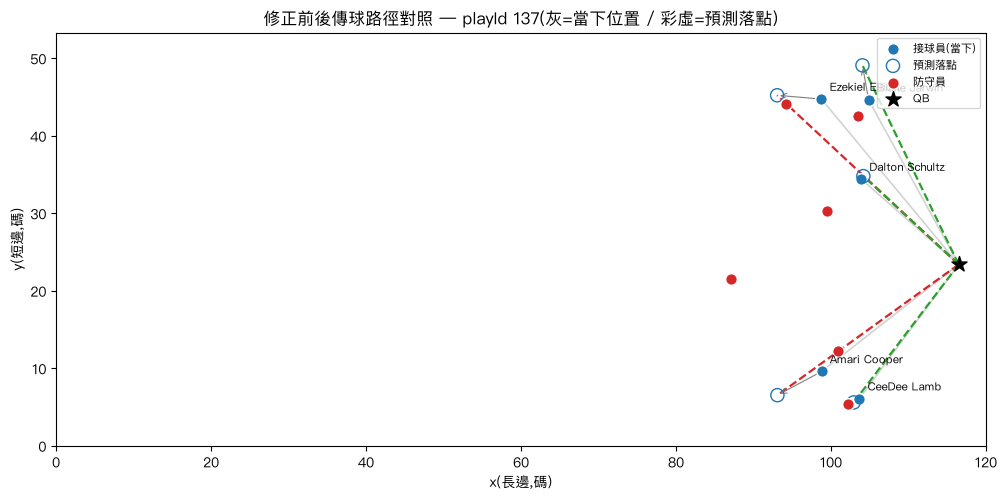

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

for _, r in receivers.iterrows():
    # 當下位置路徑:灰實線
    ax.plot([qb_xy[0], r["x"]], [qb_xy[1], r["y"]], color="lightgray", linewidth=1.2, zorder=1)
    # 預測落點路徑:彩色虛線,顏色依修正後是否乾淨
    md = lane_min(r["pred_x"], r["pred_y"])
    color = "tab:green" if (np.isnan(md) or md >= 3) else ("orange" if md >= 1.5 else "tab:red")
    ax.plot([qb_xy[0], r["pred_x"]], [qb_xy[1], r["pred_y"]], "--", color=color, linewidth=1.6, zorder=2)
    # 當下位置 -> 預測落點 的小箭頭
    ax.annotate("", xy=(r["pred_x"], r["pred_y"]), xytext=(r["x"], r["y"]),
                arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))

ax.scatter(receivers["x"], receivers["y"], c="tab:blue", s=70, edgecolor="white", label="接球員(當下)", zorder=3)
ax.scatter(receivers["pred_x"], receivers["pred_y"], facecolors="none", edgecolors="tab:blue",
           s=90, label="預測落點", zorder=3)
ax.scatter(defenders["x"], defenders["y"], c="tab:red", s=70, edgecolor="white", label="防守員", zorder=3)
ax.scatter([qb_xy[0]], [qb_xy[1]], c="black", s=130, marker="*", label="QB", zorder=4)

for _, r in receivers.iterrows():
    ax.annotate(r["displayName"], (r["x"], r["y"]), textcoords="offset points", xytext=(6, 6), fontsize=8)

ax.set_xlim(0, 120); ax.set_ylim(0, 53.3); ax.set_aspect("equal")
ax.set_xlabel("x(長邊,碼)"); ax.set_ylabel("y(短邊,碼)")
ax.set_title(f"修正前後傳球路徑對照 — playId {SAMPLE_PLAY_ID}(灰=當下位置 / 彩虛=預測落點)")
ax.legend(loc="upper right", fontsize=8)
plt.show()

## 本階段完成了什麼(以及沒做到什麼)

- **先誠實面對資料限制**:這份資料幾乎沒有球飛行軌跡與落點(92 傳球 play 只有 3 個 pass_arrived),所以原本「用球的實際落點」的構想**做不到**。
- 改用資料裡**真實存在**的接球員速度 `s` 與方向 `dir`,等速外推「預測落點」。外推本身是可信的(Cooper 外推 0.5s 與真實後續位置吻合)。
- **但用資料檢驗後發現:這個修正沒有解決痛點。** 對示範的深傳 play,把路徑終點換成預測落點後,Cooper 的路徑風險反而更擠(0.76 → 0.03 碼)。
- **定位出真正的根因**:passing lane 只看平面上「防守員離直線多近」,沒有考慮**球的高度與弧線**。深傳的球從防守員頭上飛過,平面指標必然誤判 —— 換路徑終點修不了這個本質問題。

**這一階段的真正價值**:不是「修好了」,而是**用資料誠實地證明一條路行不通,並找到問題的真正源頭**。這正是這個專案一路堅持的原則 —— 先用資料算、再下結論,即使結論是『此路不通』。

**下一階段(等你確認理解後再開始)**:
1. **接受 passing lane 的平面侷限,把它定位成『輔助參考』而非主指標**,在 play 卡上標註它對深傳不可靠,避免誤導教練。
2. **回到更穩固的指標(separation、Voronoi)做包裝**:批次產出報告或互動介面,先把確實可信的分析交付出去。
3. **若未來拿到含球飛行高度 / 完整軌跡的資料集**,才有機會做出真正考慮弧線的傳球可行性指標。